# CMCRL on the CDD leaf subset — minimal reproduction

**Paper:** Jun Chen, Yonghua Yu, Weifu Li, Yaohui Chen, Hong Chen.
*Clustering-Guided Multi-Layer Contrastive Representation Learning for Citrus Disease Classification.*
[arXiv:2507.11171v1](https://arxiv.org/abs/2507.11171) (only version), DOI `10.48550/arxiv.2507.11171`.

**Author code:** https://github.com/cjml0808/CMCRL pinned at commit `e46a5e5ecae64a5559bee5c5c32f0b54820e7bf7`
(no LICENSE file in the repository; used here for non-commercial educational reproduction).

**Dataset:** CDD — *A Citrus Fruits and Leaves Dataset for Detection and Classification of Citrus Diseases through Machine Learning* (Rauf et al.), Mendeley Data v2, DOI `10.17632/3f83gxmv57.2`, **CC BY 4.0**.

## What this notebook does (scope)

Executes the paper's **CMCRL self-supervised pre-training** on the **CDD leaf subset** (609 images, 5 classes:
Black spot / canker / greening / Melanose / healthy), following the released `examples/train_cdd.py` pipeline:

1. ResNet50-IBN (`resnet_ibn50a_ori`) embeddings, 256×256 inputs, embedding dim 512.
2. Per-epoch: jaccard-distance DBSCAN pseudo-labels (eps 0.4, k1 30, k2 6, min_samples 4) → cluster centroids memory (temp 0.05, momentum 0.1) → InfoNCE contrastive training (Adam, lr 3.5e-4, wd 5e-4, batch 16, 4 instances... instances are implicit in the sampler-free shuffle used by the released script).
3. Frozen-encoder **linear probe** + top-1 accuracy and macro recall / precision / F1 on 124 held-out test images (paper Tables II/V protocol).
4. Clustering metrics (CACC via Hungarian matching, ARI) on the 485 pre-training images, and a t-SNE embedding view.
5. Small comparison: pre-trained vs random-init encoder (mirrors the paper's Table IV narrative).

**Paper reference values (full-scale, reported for context — NOT expected from this small run):**
CDD downstream ACC 0.938; CACC 0.600, ARI 0.228 (Table II); recall/precision/F1 = 94.75/94.43/93.50% (Table V).

| 項目 | 内容 |
|---|---|
| 実行環境 | **T4 GPU 必須**（著者コードが `.cuda()` 前提のため CPU では実行不可） |
| 所要時間の目安 | 約 15 分（セットアップ約 3 分、ダウンロード約 170 MB、事前学習約 7 分） |
| スコープ | CDD 葉サブセット 609 枚による最小再現（485 枚事前学習 + 124 枚評価） |

**AI-assisted adaptation notice / AI による適合の明示:**
The notebook reuses the authors' pinned code and their documented hyperparameters, but the **dataset conversion
(Mendeley archive → the pickle format `dc/datasets/CDD.py` expects) and the 485/124 split are AI-written glue**;
the authors did not release their converted pickles or the split member list. Probe/linear-head settings not
specified for CDD in the paper are documented below. Untested behavior is not guaranteed.
**（本ノートブックは著者コードを利用するが、データセット変換と 485/124 分割は AI 作成のグルーコードです。）**

**References / 参考:** paper §III-A (datasets), §III-B (CMCRL), §IV (settings: 256×256, RHF 0.5, Pad 10, RE fill
[0.485,0.456,0.406], d=512, eps 0.4, k1=30, k2=6, α=0.1, τ=0.05); `examples/train_cdd.py` defaults
(epochs 10, iters 100, lr 3.5e-4).

## 0. Runtime selection / 実行環境の選択

**Select Runtime → Change runtime type → T4 GPU before Run all.**（実行前に T4 GPU を選択してください。）

The author pipeline hard-codes `.cuda()` in `dc/trainers.py`, `dc/evaluators.py`, and `dc/models/cm.py`, and the
paper trained on an NVIDIA RTX 2070. A CPU runtime cannot run this notebook faithfully; the next cell **fails
explicitly** if no GPU is present (no silent fallback).

**Expected duration:** ~15 minutes end-to-end on a fresh T4 runtime (setup ≈3 min, downloads ≈170 MB,
pre-training ≈7 min, evaluation ≈1 min). Free-tier availability and speed may differ.

In [ ]:
import torch, sys

if not torch.cuda.is_available():
    raise RuntimeError(
        "This reproduction requires a GPU runtime (author code is CUDA-only). "
        "In Colab: Runtime > Change runtime type > T4 GPU, then Run all again. / "
        "GPU ランタイムを選択してから再実行してください。"
    )
device = torch.device("cuda")
print("Python:", sys.version.split()[0])
print("torch:", torch.__version__, "| CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15
torch: 2.11.0+cu130 | CUDA: 13.0
GPU: Tesla T4


## 1. Dependencies / 依存ライブラリ

The pinned author code imports: `torch`, `sklearn` (DBSCAN, metrics), `faiss`
(`dc/utils/faiss_rerank.py` imports faiss at module level), `numpy`, `scipy`, `PIL`, `matplotlib`.
Colab preinstalls all except **faiss**; we install the CPU build (the author default
`search_option=3` uses CPU faiss even on GPU machines).

In [ ]:
import subprocess, importlib

def ensure_pip(import_name, pip_name):
    try:
        return importlib.import_module(import_name)
    except ModuleNotFoundError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name], check=True)
        return importlib.import_module(import_name)

faiss = ensure_pip("faiss", "faiss-cpu")  # author default search_option=3 uses CPU faiss
import sklearn, numpy, scipy, PIL, matplotlib
print("faiss:", faiss.__version__, "| sklearn:", sklearn.__version__,
      "| numpy:", numpy.__version__, "| scipy:", scipy.__version__)

faiss: 1.15.1 | sklearn: 1.6.1 | numpy: 2.1.3 | scipy: 1.16.3


## 2. Author code at the pinned commit / 著者コードの取得

Partial clone inside Colab of `cjml0808/CMCRL` at the verified commit `e46a5e5…` (blob-filtered, then a
single-commit checkout in detached HEAD). The cell asserts the checked-out SHA matches the pin.
Expected result: `HEAD: e46a5e5ecae64a5559bee5c5c32f0b54820e7bf7` and a listing of the `dc` package.

**（著者リポジトリをピン留めコミットで部分クローンし、SHA を検証します。）**

In [ ]:
%%bash
cd /content
rm -rf CMCRL
git clone --quiet --filter=blob:none --no-checkout https://github.com/cjml0808/CMCRL.git CMCRL
cd CMCRL
git fetch --quiet --depth 1 origin e46a5e5ecae64a5559bee5c5c32f0b54820e7bf7
git checkout --quiet FETCH_HEAD
echo "HEAD: $(git rev-parse HEAD)"
test "$(git rev-parse HEAD)" = "e46a5e5ecae64a5559bee5c5c32f0b54820e7bf7" || { echo "COMMIT MISMATCH"; exit 1; }
ls dc/ dc/models/ | head -20

HEAD: e46a5e5ecae64a5559bee5c5c32f0b54820e7bf7
dc/:
datasets
evaluators.py
__init__.py
models
trainers.py
utils

dc/models/:
alexnet.py
cm.py
cm___.py
densenet.py
__init__.py
mobilenetv2.py
pooling.py
resnet_ibn_a.py
resnet_ibn.py
resnet_ibn__.py
resnet.py


### 2b. Minimal compatibility patch / 最小限の互換パッチ

`dc/datasets/__init__.py` (pinned commit) imports three dataset modules — `Citrus_disease_6`,
`Citrus_disease_7`, `Citrus_disease_4` — **that are absent from the repository tree** (the paper's private
CitrusDisease7 data pipeline). This makes every `import dc` fail. We comment out only those entries; all other
author code is untouched. Expected result: the patched lines printed, then `dc` imports cleanly.

**（欠落している 3 モジュールの import だけをコメントアウトする最小パッチです。）**

In [ ]:
from pathlib import Path

init_path = Path("/content/CMCRL/dc/datasets/__init__.py")
src = init_path.read_text()
for mod in ["Citrus_disease_6", "Citrus_disease_7", "Citrus_disease_4"]:
    src = src.replace(f"from .{mod} import {mod}", f"# PATCHED(absent from repo): from .{mod} import {mod}")
    src = src.replace(f"    '{'citrusdisease' + mod[-1]}': {mod},",
                      f"    # PATCHED(absent): '{'citrusdisease' + mod[-1]}': {mod},")
init_path.write_text(src)
print("\n".join(l for l in src.splitlines() if "PATCHED" in l))

# PATCHED(absent from repo): from .Citrus_disease_6 import Citrus_disease_6
# PATCHED(absent from repo): from .Citrus_disease_7 import Citrus_disease_7
# PATCHED(absent from repo): from .Citrus_disease_4 import Citrus_disease_4
    # PATCHED(absent): 'citrusdisease6': Citrus_disease_6,
    # PATCHED(absent): 'citrusdisease7': Citrus_disease_7,
    # PATCHED(absent): 'citrusdisease4': Citrus_disease_4,


## 3. CDD dataset download (Mendeley, CC BY 4.0) / データセット入手

We use the dataset's official "Download All" endpoint (`/public-api/zip/…`) discovered from the Mendeley
site's own bundle, and validate the payload is a real ZIP. Expected result: `HTTP 200`, ~66.9 MB, then the
nested `Citrus.zip` is extracted. All dataset bytes stay on the Colab VM under `/content`.

**（Mendeley の公式ダウンロード経路で 66.9 MB の ZIP を取得し、Colab 上で展開します。DGX へは取得しません。）**

In [ ]:
import subprocess, os, zipfile, time

os.makedirs("/content/data", exist_ok=True)
zip_url = "https://data.mendeley.com/public-api/zip/3f83gxmv57/download/2"
ok = False
for attempt in range(1, 5):  # Mendeley endpoints are intermittently flaky (observed 502/22); bounded retries
    r = subprocess.run(["curl", "-sSL", "--fail", "--connect-timeout", "20", "--max-time", "1800",
                        "-o", "/content/cdd_outer.zip", "-w", "%{http_code} %{size_download}\n", zip_url])
    size = os.path.getsize("/content/cdd_outer.zip") if os.path.exists("/content/cdd_outer.zip") else 0
    if r.returncode == 0 and size > 1_000_000 and zipfile.is_zipfile("/content/cdd_outer.zip"):
        ok = True
        print(f"attempt {attempt}: OK ({size} bytes)")
        break
    print(f"attempt {attempt}: failed (curl rc={r.returncode}, size={size}); retrying in 20 s")
    time.sleep(20)
assert ok, "Mendeley download failed after 4 bounded attempts; rerun this cell later."
with zipfile.ZipFile("/content/cdd_outer.zip") as z:
    inner = [n for n in z.namelist() if n.endswith(".zip")]
    print("entries:", z.namelist())
    assert len(inner) == 1, f"unexpected outer archive layout: {z.namelist()}"
    z.extract(inner[0], "/content/cdd_extract")
    with zipfile.ZipFile(f"/content/cdd_extract/{inner[0]}") as zi:
        zi.extractall("/content/cdd_extract")
print("extracted to /content/cdd_extract")

attempt 1: failed (curl rc=22, size=0); retrying in 20 s


attempt 2: failed (curl rc=22, size=0); retrying in 20 s


attempt 3: failed (curl rc=22, size=0); retrying in 20 s


attempt 4: OK (66932231 bytes)
entries: ['A Citrus Fruits and Leaves Dataset for Detection and Classification of Citrus Diseases through Machine Learning/Citrus Plant Dataset/Citrus.zip']


extracted to /content/cdd_extract


## 4. Pretrained ResNet50-IBN backbone / 事前学習済みバックボーン

The paper's encoder is ResNet-IBN-a (IBN-Net, ECCV 2018). The pinned author code loads it from a hardcoded
Windows path (`dc/models/resnet_ibn_a.py`, `model_urls['ibn_resnet50a'] = 'E:/Code/...'`) that cannot work; we
download the **official IBN-Net release weights** and point `model_urls` at the local file.
Expected result: the SHA-256 (`d9d0bb7b…`) matching the release filename suffix, and a successful forward pass
with output shape `(2, 512)`.

**（著者コードのハードコードされた Windows パスを、IBN-Net 公式リリースの重みで置き換えます。）**

In [ ]:
import hashlib, torch, subprocess, sys

WEIGHTS_URL = "https://github.com/XingangPan/IBN-Net/releases/download/v1.0/resnet50_ibn_a-d9d0bb7b.pth"
WEIGHTS_SHA256 = "d9d0bb7b2ba34d7e6e12c4616c9d233914762e49fbb9fcb49d7f4d65da6f759c"
os.makedirs("/content/weights", exist_ok=True)
wpath = "/content/weights/resnet50_ibn_a-d9d0bb7b.pth"
if not os.path.exists(wpath):
    subprocess.run(["curl", "-sSL", "--fail", "--connect-timeout", "20", "--max-time", "1200",
                    "-o", wpath, WEIGHTS_URL], check=True)
digest = hashlib.sha256(open(wpath, "rb").read()).hexdigest()
print("sha256:", digest)
assert digest == WEIGHTS_SHA256, "weight checksum mismatch"

sys.path.insert(0, "/content/CMCRL")
from dc import models
from dc.models import resnet_ibn_a
resnet_ibn_a.model_urls["ibn_resnet50a"] = wpath  # author loads via this dict; original value is a Windows path

model = models.create("resnet_ibn50a_ori", num_features=512, norm=True, dropout=0,
                      num_classes=0, pooling_type="gem")
print("num_features:", model.num_features)

sha256: d9d0bb7b2ba34d7e6e12c4616c9d233914762e49fbb9fcb49d7f4d65da6f759c
pooling_type: gem


num_features: 512


## 5. Build the CDD pickle split / CDD データセットの変換と分割

`dc/datasets/CDD.py` expects two CIFAR-style pickles (`data` = uint8 N×256×256×3 arrays, `labels`,
`filenames`, `class_num`, `label_names`) under `<root>/cdd`. The authors did not release theirs, so we build
them from the Mendeley leaf images with a **deterministic stratified split**:

- 609 leaf images (Black spot 171, canker 163, greening 204, healthy 58, Melanose 13 — counts verified
  against the archive in the preview below).
- Largest-remainder stratified allocation → exactly **485 train / 124 test** per the paper (§III-A).
- `numpy.RandomState(1)`, per-class shuffles; filenames are class-prefixed to stay unique
  (the author evaluator indexes feature dicts by filename).
- Images are stored as 256×256 uint8 (the author transform re-resizes anyway; `Image.BICUBIC` = the
  `interpolation=3` used by the released loader).

**（著者の pickle 形式に、論文通り 485/124 の層化分割で変換します。シード固定・クラス別接頭辞付きファイル名。）**

In [ ]:
import glob, pickle, numpy as np
from PIL import Image

LEAF_ROOT = "/content/cdd_extract/Citrus/Leaves"
label_names = ["Black spot", "canker", "greening", "Melanose", "healthy"]
items = []
for cid, cname in enumerate(label_names):
    for f in sorted(glob.glob(os.path.join(LEAF_ROOT, cname, "*"))):
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            items.append((f, cid))
counts = {label_names[c]: 0 for c in range(5)}
for _, c in items:
    counts[label_names[c]] += 1
print("leaf counts:", counts, "total:", len(items))
assert len(items) == 609 and counts["Melanose"] == 13, "unexpected archive layout"

n_total, n_test_total = len(items), 124
# per-class shuffled order (deterministic, seed 1)
rng = np.random.RandomState(1)
chunks = {}
for cid in range(5):
    idx = [i for i, (f, c) in enumerate(items) if c == cid]
    rng.shuffle(idx)
    chunks[cid] = idx
# largest-remainder allocation of the 124 test images across classes
n_te = {}
frac = []
for cid in range(5):
    n_c = len(chunks[cid])
    exact = n_c * n_test_total / n_total
    n_te[cid] = int(np.floor(exact))
    frac.append((exact - np.floor(exact), cid))
remaining = n_test_total - sum(n_te.values())
for _, cid in sorted(frac, reverse=True)[:remaining]:
    n_te[cid] += 1

train_idx, test_idx = [], []
for cid in range(5):
    test_idx += chunks[cid][:n_te[cid]]
    train_idx += chunks[cid][n_te[cid]:]
print("test per class:", {label_names[c]: n_te[c] for c in range(5)})
print("train:", len(train_idx), "test:", len(test_idx))
assert len(train_idx) == 485 and len(test_idx) == 124

def build_pickle(idxs):
    data, labels, filenames = [], [], []
    for i in idxs:
        f, c = items[i]
        img = Image.open(f).convert("RGB").resize((256, 256), Image.BICUBIC)
        data.append(np.asarray(img, dtype=np.uint8))
        labels.append(c)
        filenames.append(f"{label_names[c]}/{os.path.basename(f)}")
    return {"data": np.stack(data), "labels": labels, "filenames": filenames,
            "class_num": 5, "label_names": label_names}

os.makedirs("/content/data/cdd", exist_ok=True)
with open("/content/data/cdd/train", "wb") as f:
    pickle.dump(build_pickle(train_idx), f)
with open("/content/data/cdd/test", "wb") as f:
    pickle.dump(build_pickle(test_idx), f)
print("pickles written to /content/data/cdd/")

leaf counts: {'Black spot': 171, 'canker': 163, 'greening': 204, 'Melanose': 13, 'healthy': 58} total: 609
test per class: {'Black spot': 35, 'canker': 33, 'greening': 41, 'Melanose': 3, 'healthy': 12}
train: 485 test: 124


pickles written to /content/data/cdd/


### 5b. Load through the author's dataset class / 著者のデータセットクラスで読み込み

We now load the converted pickles through the **author's own `dc.datasets.create('cdd', ...)`** to prove the
conversion matches what `examples/train_cdd.py` expects. Expected result: `Dataset statistics: train 5 ids /
485 images, test 5 ids / 124 images`.

**（変換した pickle を著者コードで読み込み、485/124 枚・5 クラスであることを確認します。）**

In [ ]:
from dc import datasets

dataset = datasets.create("cdd", "/content/data")
assert len(dataset.train) == 485 and len(dataset.test) == 124
print("OK: train", len(dataset.train), "| test", len(dataset.test),
      "| classes", dataset.class_num, dataset.label_names)

=> CDD loaded
Dataset statistics:
  ----------------------------------------
  subset   | # ids | # images
  ----------------------------------------
  train    |     5 |      485 
  test     |     5 |      124 
  ----------------------------------------
OK: train 485 | test 124 | classes 5 ['Black spot', 'canker', 'greening', 'Melanose', 'healthy']


## 6. Input preview / 入力画像のプレビュー

Sample images straight from the converted split, shown per class with their labels (this is the same data the
pre-training consumes). The class bar chart shows the imbalance the paper highlights (Melanose has only 13
leaf images; imbalance ratio ≈ 1:15.7).

**（変換済みデータから各クラスの見本画像とクラス分布を表示します。）**

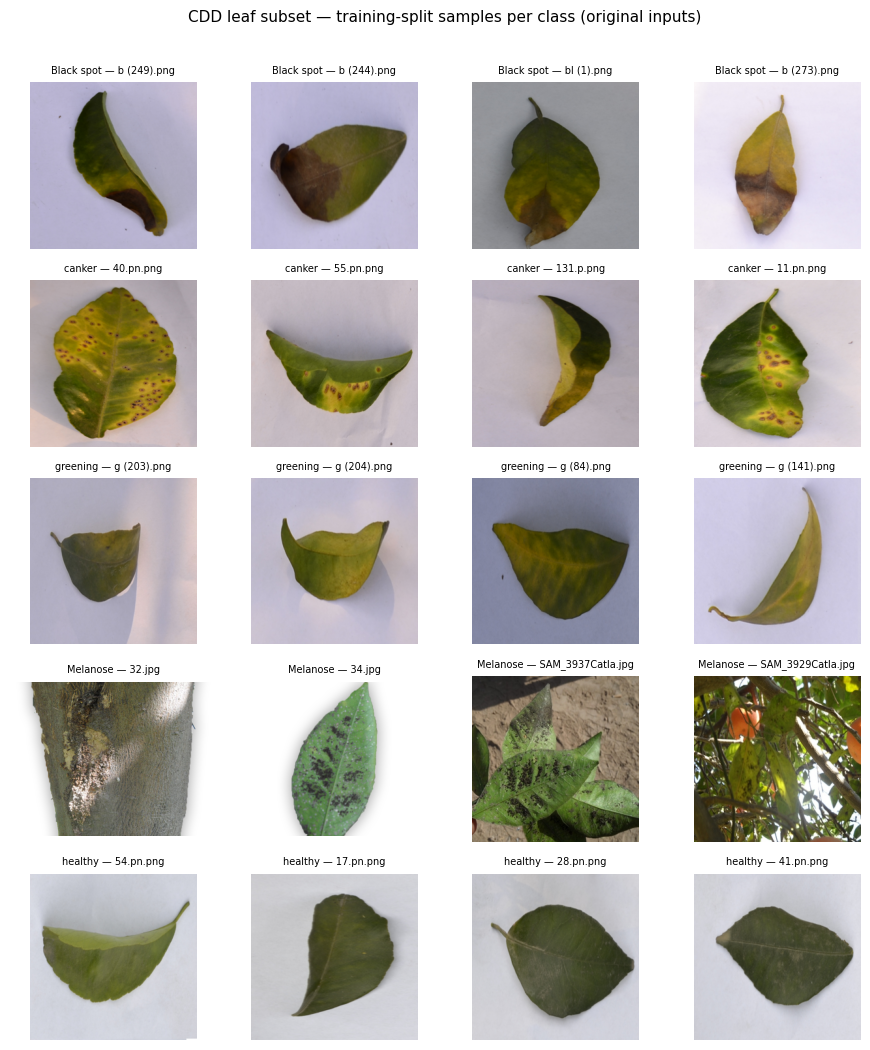

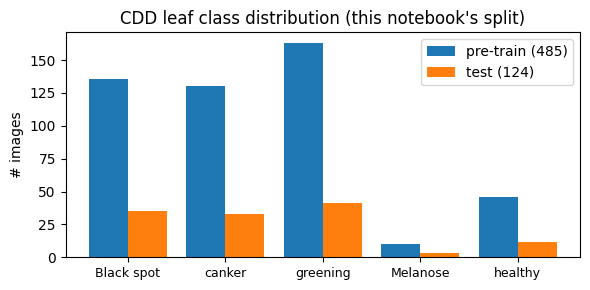

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 4, figsize=(9, 11))
for row, cname in enumerate(label_names):
    pool = [i for i in train_idx if items[i][1] == row][:4]
    for col in range(4):
        ax = axes[row][col]
        if col < len(pool):
            f, c = items[pool[col]]
            ax.imshow(Image.open(f).convert("RGB"))
            if col == 0:
                ax.set_ylabel(cname, fontsize=9)
            ax.set_title(f"{cname} — {os.path.basename(f)[:18]}", fontsize=7)
        ax.axis("off")
fig.suptitle("CDD leaf subset — training-split samples per class (original inputs)", fontsize=11)
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig("/content/cdd_input_preview.png", dpi=100, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(figsize=(6, 3))
train_counts = [sum(1 for i in train_idx if items[i][1] == c) for c in range(5)]
test_counts = [sum(1 for i in test_idx if items[i][1] == c) for c in range(5)]
x = np.arange(5)
ax2.bar(x - 0.2, train_counts, 0.4, label="pre-train (485)")
ax2.bar(x + 0.2, test_counts, 0.4, label="test (124)")
ax2.set_xticks(x); ax2.set_xticklabels(label_names, fontsize=9)
ax2.set_ylabel("# images")
ax2.set_title("CDD leaf class distribution (this notebook's split)")
ax2.legend()
fig2.tight_layout()
plt.savefig("/content/cdd_class_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

## 7. Pre-training setup: transforms, model, loaders / 事前学習の準備

We instantiate the exact augmentation pipeline of `examples/train_cdd.py::get_train_loader`
(Resize 256 bicubic → RHF p=0.5 → Pad 10 → RandomCrop → ToTensor → Normalize → RandomErasing p=0.5) and the
test transform (Resize + normalize). The model is the author's `resnet_ibn50a_ori` wrapped in `nn.DataParallel`
exactly as `create_model()` does. The optimizer matches the released defaults: Adam lr 3.5e-4, weight decay
5e-4, StepLR γ=0.1 every 20 epochs (inactive within our 10 epochs).

**（著者の train_cdd.py と同じ増強パイプライン・モデル構成・最適化設定を用います。）**

In [ ]:
from torch import nn
from torch.utils.data import DataLoader
from dc.utils.data import IterLoader
from dc.utils.data import transforms as T
from dc.utils.data.preprocessor import Preprocessor

normalizer = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transformer = T.Compose([
    T.Resize((256, 256), interpolation=3),
    T.RandomHorizontalFlip(p=0.5),
    T.Pad(10),
    T.RandomCrop((256, 256)),
    T.ToTensor(),
    normalizer,
    T.RandomErasing(probability=0.5, mean=[0.485, 0.456, 0.406]),
])
test_transformer = T.Compose([T.Resize((256, 256), interpolation=3), T.ToTensor(), normalizer])

model = nn.DataParallel(model.cuda())
model.train()

params = [{"params": [v]} for _, v in model.named_parameters() if v.requires_grad]
optimizer = torch.optim.Adam(params, lr=3.5e-4, weight_decay=5e-4)  # train_cdd.py defaults
EPOCHS, ITERS, BATCH = 10, 100, 16  # released defaults (paper Algorithm 1: 50 epochs)

print("train transform:", train_transformer)
print("epochs:", EPOCHS, "iters/epoch:", ITERS, "batch:", BATCH)

train transform: Compose(
    Resize(size=(256, 256), interpolation=bicubic, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    Pad(padding=10, fill=0, padding_mode=constant)
    RandomCrop(size=(256, 256), padding=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
epochs: 10 iters/epoch: 100 batch: 16


## 8. CMCRL pre-training loop / CMCRL 事前学習

This is the author's `main_worker` loop (train_cdd.py L185-294), executed at the released default scale
(10 epochs × 100 iters). Every epoch:

1. Extract embeddings of the 485 unlabeled images (no labels used).
2. Compute the jaccard distance (`compute_jaccard_distance`, k1=30, k2=6) and run DBSCAN
   (eps=0.4, min_samples=4, precomputed metric) → pseudo-labels; unclustered samples (−1) are discarded.
3. Compute per-cluster centroids, store them in the momentum `ClusterMemory` (α=0.1, τ=0.05).
4. Contrast with cluster centroids via `CCTrainer` for 100 iterations.
5. Report the author's clustering metrics (CACC/NMI/ARI vs the *true* labels — evaluation only).

Expected result: the loss decreases; the clustered-sample fraction and CACC improve over epochs. On the small
CDD subset this takes ≈5-8 minutes on T4.

**（train_cdd.py の本体ループを既定スケール（10 エポック×100 イテレーション）で実行します。）**

In [ ]:
import collections, random, time
import torch.nn.functional as F
from sklearn.cluster import DBSCAN
from dc.models.cm import ClusterMemory
from dc.trainers import CCTrainer
from dc.evaluators import Evaluator, extract_features
from dc.utils.faiss_rerank import compute_jaccard_distance

seed = 1  # train_cdd.py --seed default
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True

evaluator = Evaluator(model)
trainer = CCTrainer(model)
history = []
t_start = time.time()

for epoch in range(EPOCHS):
    with torch.no_grad():
        cluster_loader = DataLoader(
            Preprocessor(dataset.train, root=dataset.images_dir, transform=test_transformer,
                         labels=dataset.train_labels, filenames=dataset.train_filenames),
            batch_size=BATCH, num_workers=2, shuffle=False, pin_memory=True)
        features, _ = extract_features(model, cluster_loader, print_freq=1000)
        features = torch.cat([features[f].unsqueeze(0) for f in dataset.train_filenames], 0)
        rerank_dist = compute_jaccard_distance(features, k1=30, k2=6, print_flag=(epoch == 0))
        pseudo_labels = DBSCAN(eps=0.4, min_samples=4, metric="precomputed", n_jobs=-1).fit_predict(rerank_dist)
        num_cluster = len(set(pseudo_labels)) - (1 if -1 in pseudo_labels else 0)

    centers = collections.defaultdict(list)
    for i, label in enumerate(pseudo_labels):
        if label != -1:
            centers[label].append(features[i])
    cluster_features = torch.stack([torch.stack(centers[k], 0).mean(0) for k in sorted(centers)], 0)

    memory = ClusterMemory(model.module.num_features, num_cluster, temp=0.05, momentum=0.1).cuda()
    memory.features = F.normalize(cluster_features, dim=1).cuda()
    trainer.memory = memory

    pl_dataset, pl_filenames, pl_labels = [], [], []
    for img, fname, label in zip(dataset.train, dataset.train_filenames, pseudo_labels):
        if label != -1:
            pl_dataset.append(img); pl_filenames.append(fname); pl_labels.append(int(label))
    pl_dataset = np.array(pl_dataset)
    train_loader = IterLoader(DataLoader(
        Preprocessor(pl_dataset, root=None, transform=train_transformer,
                     labels=pl_labels, filenames=pl_filenames),
        batch_size=BATCH, num_workers=2, shuffle=True, pin_memory=True, drop_last=True), length=ITERS)
    train_loader.new_epoch()
    trainer.train(epoch, train_loader, optimizer, print_freq=ITERS // 2, train_iters=ITERS)

    cacc = evaluator.evaluate_clustering(epoch, dataset.train_labels, pseudo_labels)
    history.append({"epoch": epoch + 1, "num_clusters": num_cluster,
                    "noise": int((np.asarray(pseudo_labels) == -1).sum()), "CACC": cacc})
    print(f"[epoch {epoch+1}/{EPOCHS}] clusters={num_cluster} noise={history[-1]['noise']} CACC={cacc:.3f}")

print("pre-training wall time: %.1f s" % (time.time() - t_start))

Computing jaccard distance...


Jaccard distance computing time cost: 0.6341664791107178


Epoch: [0][50/100]	Time 0.304 (0.322)	Data 0.000 (0.014)	Loss 2.006 (2.729)


Epoch: [0][100/100]	Time 0.313 (0.324)	Data 0.000 (0.015)	Loss 2.735 (3.019)
#Clustering Epoch 0, ACC: 47.4%, NMI: 29.5%, ARI: 14.1%.
[epoch 1/10] clusters=26 noise=246 CACC=0.474


Epoch: [1][50/100]	Time 0.332 (0.335)	Data 0.000 (0.010)	Loss 3.148 (3.294)


...

Epoch: [7][100/100]	Time 0.341 (0.349)	Data 0.004 (0.011)	Loss 6.523 (2.072)
#Clustering Epoch 7, ACC: 55.1%, NMI: 34.9%, ARI: 17.6%.
[epoch 8/10] clusters=17 noise=96 CACC=0.551


Epoch: [8][50/100]	Time 0.333 (0.344)	Data 0.000 (0.006)	Loss 2.150 (1.610)


Epoch: [8][100/100]	Time 0.337 (0.346)	Data 0.000 (0.007)	Loss 0.783 (1.599)
#Clustering Epoch 8, ACC: 50.9%, NMI: 35.2%, ARI: 14.7%.
[epoch 9/10] clusters=21 noise=85 CACC=0.509


Epoch: [9][50/100]	Time 0.332 (0.341)	Data 0.000 (0.006)	Loss 1.168 (1.345)


Epoch: [9][100/100]	Time 0.335 (0.343)	Data 0.000 (0.008)	Loss 2.412 (1.462)
#Clustering Epoch 9, ACC: 52.0%, NMI: 34.0%, ARI: 12.9%.
[epoch 10/10] clusters=16 noise=75 CACC=0.520
pre-training wall time: 386.3 s


### 8b. Pre-training history / 学習の履歴

A compact table of the per-epoch clustering behavior (clusters found, noise count, CACC). With only 10 epochs
this is a *reduced-scale* run — the paper trains 50 epochs (Algorithm 1) and reports CACC 0.600 / ARI 0.228 on
CDD (Table II); our numbers are expected to be lower and noisier.

**（エポックごとのクラスタ数・ノイズ数・CACC の履歴です。縮小スケールのため論文値より低くなるのは想定内です。）**

In [ ]:
import pandas as pd

hist_df = pd.DataFrame(history)
print(hist_df.to_string(index=False))
hist_df.to_csv("/content/cmcrl_pretraining_history.csv", index=False)

 epoch  num_clusters  noise     CACC
     1            26    246 0.474227
     2            19    109 0.538144
     3            20    103 0.544330
     4            18    114 0.569072
     5            17    106 0.503093
     6            17     84 0.492784
     7            16     98 0.534021
     8            17     96 0.550515
     9            21     85 0.509278
    10            16     75 0.519588


## 9. Embedding visualization / 埋め込みの可視化

t-SNE of the final 512-d embeddings of the 485 pre-training images, colored by **true class** (left) and by
**DBSCAN pseudo-label** (right). This mirrors the paper's Fig. 5 cluster visualization (author code:
`evaluators.feature_for_tsne_embedding`); the panel layout is this notebook's own.

**（最終埋め込みを t-SNE で可視化します。左=真のクラス、右=DBSCAN 疑似ラベル。）**

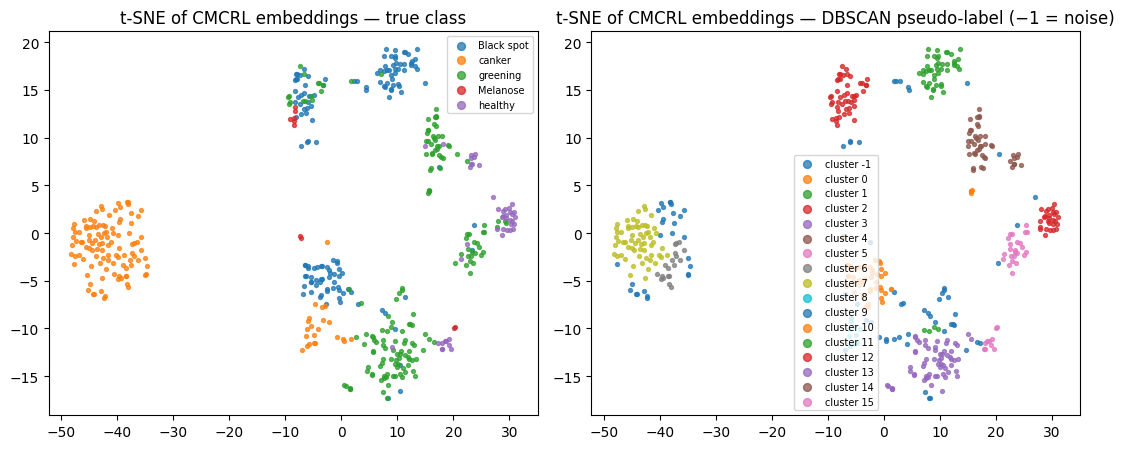

In [ ]:
from sklearn.manifold import TSNE

X = features.cpu().numpy().astype(np.float64)
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=seed)
P = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, lab, title in [(axes[0], np.array(dataset.train_labels), "true class"),
                       (axes[1], np.asarray(pseudo_labels), "DBSCAN pseudo-label (−1 = noise)")]:
    for c in sorted(set(lab.tolist())):
        m = lab == c
        name = label_names[c] if title.startswith("true") and c >= 0 else f"cluster {c}"
        ax.scatter(P[m, 0], P[m, 1], s=8, label=name, alpha=0.75)
    ax.set_title(f"t-SNE of CMCRL embeddings — {title}")
    ax.legend(fontsize=7, markerscale=2)
fig.tight_layout()
plt.savefig("/content/cmcrl_tsne.png", dpi=100, bbox_inches="tight")
plt.show()

## 10. Frozen-encoder linear probe / 凍結エンコーダでの線形評価

Following the paper's fine-tuning protocol (§III-B: frozen encoder, linear head `g`), we:

1. Freeze the pre-trained encoder and extract 512-d features (test transform) of the 485 train and 124 test images.
2. Train a linear head on the train features **with labels revealed** (the paper does not itemize the CDD
   fine-tuning set X′; with only 485+124 CDD images, using the 485 as the small-scale labeled set is the
   documented assumption here — probe hyperparameters are likewise not specified for CDD, so we use plain
   Adam lr 1e-3, 300 full-batch steps).
3. Evaluate top-1 accuracy and macro recall / precision / F1 on the 124 test images (paper Table V metrics).

**（凍結エンコーダの特徴量で線形分類ヘッドを学習し、124 枚のテスト画像で精度/再現率/適合率/F1 を評価します。）**

In [ ]:
def extract_split_features(m):
    m.eval()
    out = {}
    with torch.no_grad():
        for split, entries, labels_, fnames in [
            ("train", dataset.train, dataset.train_labels, dataset.train_filenames),
            ("test", dataset.test, dataset.test_labels, dataset.test_filenames),
        ]:
            loader = DataLoader(Preprocessor(entries, root=None, transform=test_transformer,
                                             labels=labels_, filenames=fnames),
                                batch_size=BATCH, shuffle=False, pin_memory=True)
            feats = []
            for imgs, _, _, _ in loader:
                feats.append(m(imgs.cuda()).cpu())
            out[split] = torch.cat(feats, 0)
    return out

def linear_probe(feats, steps=300, lr=1e-3):
    head = nn.Linear(512, 5).cuda()
    opt = torch.optim.Adam(head.parameters(), lr=lr, weight_decay=5e-4)
    X, y = feats["train"].cuda(), torch.tensor(dataset.train_labels).cuda()
    head.train()
    for _ in range(steps):
        opt.zero_grad()
        loss = F.cross_entropy(head(X), y)
        loss.backward(); opt.step()
    head.eval()
    with torch.no_grad():
        pred = head(feats["test"].cuda()).argmax(1).cpu().numpy()
    return np.asarray(dataset.test_labels), pred

feats_pre = extract_split_features(model)
y_true, y_pred_pre = linear_probe(feats_pre)

### 10b. Metrics + random-init comparison / 指標とランダム初期化との比較

We compute top-1 accuracy and macro recall / precision / F1 (paper Table V metric family) for
(a) the CMCRL pre-trained encoder and (b) the same architecture with random initialization (no pre-training),
mirroring the paper's Table IV pre-training-vs-random-init comparison at demonstration scale.
Expected result: the pre-trained encoder scores higher; both accuracies are below the paper's full-scale
93.8% because this run is 10 epochs on 485 images. A CSV of the results is exported to
`/content/cmcrl_results.csv`.

**（CMCRL 事前学習器とランダム初期化の比較表を作成し、CSV に出力します。）**

In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

def metrics_of(y, pred):
    return {"ACC": accuracy_score(y, pred),
            "macro_recall": recall_score(y, pred, average="macro"),
            "macro_precision": precision_score(y, pred, average="macro"),
            "macro_f1": f1_score(y, pred, average="macro")}

rows = [{"encoder": "CMCRL pre-trained (10 epochs)", **metrics_of(y_true, y_pred_pre)}]

rand_model = nn.DataParallel(models.create(
    "resnet_ibn50a_ori", num_features=512, norm=True, dropout=0, num_classes=0,
    pooling_type="gem", pretrained=False).cuda())
feats_rand = extract_split_features(rand_model)
_, y_pred_rand = linear_probe(feats_rand)
rows.append({"encoder": "random init (no pre-training)", **metrics_of(y_true, y_pred_rand)})

res_df = pd.DataFrame(rows).assign(dataset="CDD leaf 124-image test")
print(res_df.to_string(index=False))
res_df.to_csv("/content/cmcrl_results.csv", index=False)

pooling_type: gem


                      encoder      ACC  macro_recall  macro_precision  macro_f1                 dataset
CMCRL pre-trained (10 epochs) 0.911290      0.855958         0.934872  0.886943 CDD leaf 124-image test
random init (no pre-training) 0.330645      0.200000         0.066129  0.099394 CDD leaf 124-image test


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 10c. Result graph / 結果のグラフ

Bar chart of the comparison above (this notebook's own visualization, not an author figure). The pre-trained
encoder should beat random initialization; the gap illustrates the paper's core claim at demonstration scale.

**（線形評価の比較棒グラフです。事前学習の利得が論文の主張の小型実証になります。）**

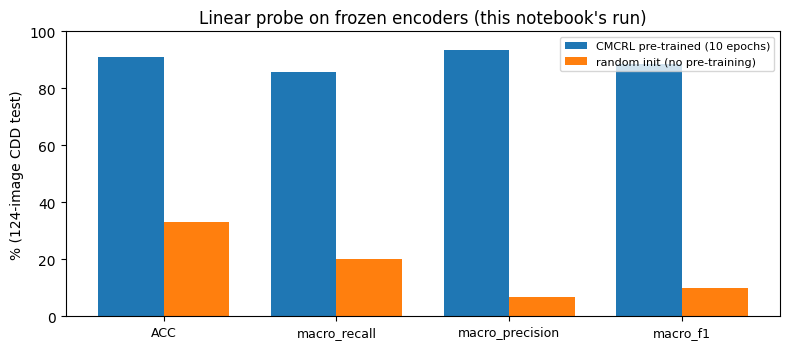

Reference (full paper, do not expect a match at this scale):
  CDD downstream ACC 0.938 (Table II); recall/precision/F1 = 94.75/94.43/93.50 (Table V).
  This run: 10 epochs x 100 iters on 485 images (released train_cdd.py defaults).


In [ ]:
metric_cols = ["ACC", "macro_recall", "macro_precision", "macro_f1"]
fig3, ax3 = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(metric_cols))
w = 0.38
for k, (_, row) in enumerate(res_df.iterrows()):
    ax3.bar(x + (k - 0.5) * w, [row[c] * 100 for c in metric_cols], w, label=row["encoder"])
ax3.set_xticks(x); ax3.set_xticklabels(metric_cols, fontsize=9)
ax3.set_ylabel("% (124-image CDD test)")
ax3.set_ylim(0, 100)
ax3.set_title("Linear probe on frozen encoders (this notebook's run)")
ax3.legend(fontsize=8)
fig3.tight_layout()
plt.savefig("/content/cmcrl_probe_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

print(
    "Reference (full paper, do not expect a match at this scale):\n"
    "  CDD downstream ACC 0.938 (Table II); recall/precision/F1 = 94.75/94.43/93.50 (Table V).\n"
    "  This run: 10 epochs x 100 iters on 485 images (released train_cdd.py defaults)."
)

## 11. Interpretation and limitations / 解釈と限界

**What was executed:** the authors' pinned `examples/train_cdd.py` pipeline — ResNet50-IBN embeddings,
jaccard-DBSCAN pseudo-labeling, momentum cluster-centroid memory and InfoNCE pre-training on the 485-image
CDD leaf subset — followed by a frozen-encoder linear probe on the 124-image test split, on a Colab T4.

**Differences from the paper / 論文との違い**
- Scale: 10 epochs × 100 iters (released defaults) vs 50 epochs in Algorithm 1; results are expected to be
  below the published 93.8% CDD ACC.
- The released entry script contrasts the final embedding with cluster centroids (single-layer memory); the
  paper's full multi-layer (MCT) variant is not visible in this script.
- The 485/124 split member list and the CDD fine-tuning set X′ are not published; both are documented
  deterministic adaptations (seed 1, largest-remainder stratification; linear head trained on the 485 with
  labels revealed).
- `dc/datasets/__init__.py` was patched only to skip three dataset modules absent from the repository; the
  backbone weights come from the official IBN-Net release because the pinned code points at a local
  Windows path.

**Not reproduced here:** CitrusDisease7 experiments (dataset never released), baselines (SimCLR/BYOL/…),
ablations, and full-scale benchmark numbers.

**References:** arXiv:2507.11171v1 §§III-IV; `cjml0808/CMCRL@e46a5e5` (`examples/train_cdd.py`,
`dc/models/cm.py`, `dc/trainers.py`, `dc/evaluators.py`, `dc/utils/faiss_rerank.py`);
Mendeley Data `10.17632/3f83gxmv57.2` (CC BY 4.0); IBN-Net release v1.0 (XingangPan/IBN-Net).